# Курсовая работа. Блок ML Beginner
<br>

**NB!** Код должен быть с комментариями к каждому логическому блоку кода. В противном случае работа **не** будет принята. <br><br>
Выполнение курсовой работы может потребовать использование дополнительных библиотек. Может потребоваться предварительная обработка данных.

<br><br>
**Описание работы:**
&nbsp;&nbsp;&nbsp;&nbsp;
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; Любой бизнес хочет максимизировать количество клиентов. Для достижения этой цели важно не только пытаться привлечь новых, но и удерживать уже существующих. Удержать клиента обойдется компании дешевле, чем привлечь нового. Кроме того, новый клиент может оказаться слабо заинтересованным в услугах бизнеса и с ним будет сложно работать, тогда как о старых клиентах уже есть необходимые данные по взаимодействию с сервисом.
 <br>

&nbsp;&nbsp;&nbsp;&nbsp; Соответственно, прогнозируя отток, мы можем вовремя среагировать и попытаться удержать клиента, который хочет уйти. Опираясь на данные об услугах, которыми пользуется клиент, мы можем сделать ему специальное предложение, пытаясь изменить его решение об уходе от оператора. Благодаря этому задача удержания будет легче в реализации, чем задача привлечения новых пользователей, о которых мы еще ничего не знаем.<br>

&nbsp;&nbsp;&nbsp;&nbsp; Вам предоставлен набор данных от телекоммуникационной компании. В данных содержится информация о почти шести тысячах пользователей, их демографических характеристиках, услугах, которыми они пользуются, длительности пользования услугами оператора, методе оплаты, размере оплаты.
<br>

&nbsp;&nbsp;&nbsp;&nbsp; Cтоит задача проанализировать данные и спрогнозировать отток пользователей (выявить людей, которые продлят контракт и которые не продлят). Работа должна включать в себя следующие обязательные пункты:
1. Описание данных *(с расчетом базовых статистик)*,
2. Исследование зависимостей и формулирование гипотез,
3. Построение моделей для прогнозирования оттока *(с обоснованием выбора той или иной модели)* на основе проверенных гипотез и выявленных взаимосвязей,
4. Сравнение качества полученных моделей.

Во втором разделе обязательно должно присутствовать обоснование гипотез, подробное описание выявленных взаимосвязей, а также их визуализация.
<br>В четвертом дополнительно должны быть сформулированы общие выводы работы.

<br><br>

_________

[Codebook](#Codebook) <br>
[1. Описание данных](#1.-Описание-данных)<br>
[2. Исследование зависимостей и формулирование гипотез](#2.-Исследование-зависимостей-и-формулирование-гипотез)<br>
[3. Построение моделей для прогнозирования оттока](#3.-Построение-моделей-для-прогнозирования-оттока)<br>
[4. Сравнение качества моделей](#4.-Сравнение-качества-моделей) <br>


## Codebook
<br>

[Ссылка для скачивания данных](https://drive.google.com/open?id=1dPCG76ST6NohYKtVMGv6HpFL-jD5p1eJ)
<br><br>

`telecom_users.csv` содержит следующие значения:<br><br>

&nbsp;&nbsp;&nbsp;&nbsp; `customerID` – id клиента<br>
&nbsp;&nbsp;&nbsp;&nbsp; `gender` – пол клиента (male/female)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `SeniorCitizen` – яляется ли клиент пенсионером (1, 0)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Partner` – состоит ли клиент в браке (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Dependents` – есть ли у клиента иждивенцы (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `tenure` – сколько месяцев человек являлся клиентом компании<br>
&nbsp;&nbsp;&nbsp;&nbsp; `PhoneService` – подключена ли услуга телефонной связи (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `MultipleLines` – подключены ли несколько телефонных линий (Yes, No, No phone service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `InternetService` – интернет-провайдер клиента (DSL, Fiber optic, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `OnlineSecurity` – подключена ли услуга онлайн-безопасности (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `OnlineBackup` – подключена ли услуга online backup (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `DeviceProtection` – есть ли у клиента страховка оборудования (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `TechSupport` – подключена ли услуга технической поддержки (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `StreamingTV` – подключена ли услуга стримингового телевидения (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `StreamingMovies` – подключена ли услуга стримингового кинотеатра (Yes, No, No internet service)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Contract` – тип контракта клиента (Month-to-month, One year, Two year)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `PaperlessBilling` – пользуется ли клиент безбумажным биллингом (Yes, No)<br>
&nbsp;&nbsp;&nbsp;&nbsp; `PaymentMethod` – метод оплаты (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))<br>
&nbsp;&nbsp;&nbsp;&nbsp; `MonthlyCharges` – месячный размер оплаты на настоящий момент<br>
&nbsp;&nbsp;&nbsp;&nbsp; `TotalCharges` – общая сумма, которую клиент заплатил за услуги за все время<br>
&nbsp;&nbsp;&nbsp;&nbsp; `Churn` – произошел ли отток (Yes or No)<br>

# 1. Описание данных

In [27]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


import warnings
warnings.filterwarnings('ignore')




In [28]:
# Load in the train and test datasets
telecom = pd.read_csv('telecom_users.csv')


telecom.head(5)

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1869,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,4528,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,6344,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6739,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,432,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


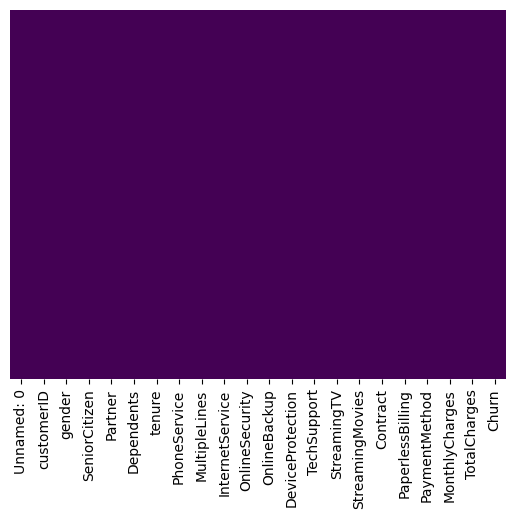

In [29]:
#анализ наполненности дата фрейма
sns.heatmap(telecom.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()


In [30]:
# Создаем функцию для анализа уникальных значений
def analyze_unique_values(df, max_categories=20):
    print("Анализ уникальных значений постолбцам")
    
    for column in df.columns:
        unique_count = df[column].nunique()
        unique_values = df[column].unique()
        
        print(f"\n Столбец: {column}")
        print(f"   Тип данных: {df[column].dtype}")
        print(f"   Количество уникальных значений: {unique_count}")
        #print(f"   Количество пропусков: {df[column].isnull().sum()}")
        
        if unique_count <= max_categories:
            print(f"   Уникальные значения: {list(unique_values)}")
        else:
            print(f"   Уникальные значения: {list(unique_values[:max_categories])} ... \nколичество остальных знач.: {unique_count - max_categories}")


#применяем анализ ко всему датафрейму
analyze_unique_values(telecom)

Анализ уникальных значений постолбцам

 Столбец: Unnamed: 0
   Тип данных: int64
   Количество уникальных значений: 5986
   Уникальные значения: [1869, 4528, 6344, 6739, 432, 2215, 5260, 6001, 1480, 5137, 3169, 4653, 2850, 1760, 604, 2157, 3132, 6765, 6508, 5636] ... 
количество остальных знач.: 5966

 Столбец: customerID
   Тип данных: object
   Количество уникальных значений: 5986
   Уникальные значения: ['7010-BRBUU', '9688-YGXVR', '9286-DOJGF', '6994-KERXL', '2181-UAESM', '4312-GVYNH', '2495-KZNFB', '4367-NHWMM', '8898-KASCD', '8016-NCFVO', '4578-PHJYZ', '2091-MJTFX', '2277-DJJDL', '2511-MORQY', '2731-GJRDG', '1784-EZDKJ', '2468-SJFLM', '5115-SQAAU', '8708-XPXHZ', '0601-WZHJF'] ... 
количество остальных знач.: 5966

 Столбец: gender
   Тип данных: object
   Количество уникальных значений: 2
   Уникальные значения: ['Male', 'Female']

 Столбец: SeniorCitizen
   Тип данных: int64
   Количество уникальных значений: 2
   Уникальные значения: [0, 1]

 Столбец: Partner
   Тип данных: obj

In [31]:
#разбиваем на категории столбцы, где есть нескольк опеременных
telecom['tenure'] = pd.to_numeric(telecom['tenure'], errors='coerce')

# Вычислим статистики
tenure_avg = telecom['tenure'].mean()
tenure_std = telecom['tenure'].std()
tenure_null_count = telecom['tenure'].isnull().sum() 

print(f"Среднее: {tenure_avg:.2f}")
print(f"Стандартное отклонение: {tenure_std:.2f}")
print(f"Пропуски: {tenure_null_count}")

Среднее: 32.47
Стандартное отклонение: 24.52
Пропуски: 0


In [32]:
#обрабатываем колонку Tenure
#создаем столбец

telecom['CategoricalTenure'] = pd.cut(telecom['tenure'], 5, duplicates='drop')
#распределение по категориям
category_counts = telecom['CategoricalTenure'].value_counts().sort_index()

In [33]:
print("распределение по категориям:")
for i, (interval, count) in enumerate(category_counts.items()):
    percentage = (count / len(telecom)) * 100
    print(f"Категория {i+1}: {interval}")
    print(f"  Количество: {count} ({percentage:.1f}%)")

распределение по категориям:
Категория 1: (-0.072, 14.4]
  Количество: 1997 (33.4%)
Категория 2: (14.4, 28.8]
  Количество: 961 (16.1%)
Категория 3: (28.8, 43.2]
  Количество: 852 (14.2%)
Категория 4: (43.2, 57.6]
  Количество: 803 (13.4%)
Категория 5: (57.6, 72.0]
  Количество: 1373 (22.9%)


In [34]:
#разбиваем на категории столбцы, где есть нескольк опеременных
telecom['MonthlyCharges'] = pd.to_numeric(telecom['MonthlyCharges'], errors='coerce')

# Вычислим статистики
Monthly_avg = telecom['MonthlyCharges'].mean()
Monthly_std = telecom['MonthlyCharges'].std()
Monthly_charges_null_count = telecom['MonthlyCharges'].isnull().sum()

print(f"Среднее: {Monthly_avg:.2f}")
print(f"Стандартное отклонение: {Monthly_std:.2f}")
print(f"Пропуски: {Monthly_charges_null_count}")

Среднее: 64.80
Стандартное отклонение: 30.11
Пропуски: 0


In [35]:
#обрабатываем колонку MonthlyCharges
#создаем столбец
telecom['CategoricalMonthlyCharges'] = pd.cut(telecom['MonthlyCharges'], 5, labels=False, duplicates='drop')

#распределение по категориям
monthly_category_counts = telecom['CategoricalMonthlyCharges'].value_counts().sort_index() 


In [36]:

print("Реальное распределение по категориям:")
for i, (interval, count) in enumerate(monthly_category_counts.items()):
    percentage1 = (count / len(telecom)) * 100
    print(f"Категория {i+1}: {interval}")
    print(f"  Количество: {count} ({percentage1:.1f}%)")
    

Реальное распределение по категориям:
Категория 1: 0
  Количество: 1524 (25.5%)
Категория 2: 1
  Количество: 868 (14.5%)
Категория 3: 2
  Количество: 1147 (19.2%)
Категория 4: 3
  Количество: 1546 (25.8%)
Категория 5: 4
  Количество: 901 (15.1%)


In [37]:
#разбиваем на категории столбцы, где есть нескольк опеременных
telecom['TotalCharges'] = pd.to_numeric(telecom['TotalCharges'], errors='coerce')

# Вычислим статистики
Total_avg = telecom['TotalCharges'].mean()
Total_std = telecom['TotalCharges'].std()
total_Total_charges_null_count = telecom['TotalCharges'].isnull().sum()

print(f"Среднее: {Total_avg:.2f}")
print(f"Стандартное отклонение: {Total_std:.2f}")
print(f"Пропуски: {total_Total_charges_null_count}")

Среднее: 2298.06
Стандартное отклонение: 2274.13
Пропуски: 10


In [38]:
#обрабатываем колонку MonthlyCharges
#создаем столбец
telecom['CategoricalTotalCharges'] = pd.cut(telecom['TotalCharges'], 5, duplicates='drop')
#распределение по категориям
TotalCharges_category_counts = telecom['CategoricalTotalCharges'].value_counts().sort_index()

In [39]:
#обрабатываем колонку TotalCharges

#заполняем пропуски
if total_Total_charges_null_count > 0:
    #более безопасный подход: используем медиану вместо нормального распределения
    total_charges_median = telecom['TotalCharges'].median()
    total_charges_iqr = telecom['TotalCharges'].quantile(0.75) - telecom['TotalCharges'].quantile(0.25)
    #генерируем значения в реалистичном диапазоне
    random_charges = np.random.uniform(max(0, total_charges_median - total_charges_iqr), total_charges_median + total_charges_iqr, size=total_Total_charges_null_count
    )
    
    telecom['TotalCharges'] = telecom['TotalCharges'].fillna(pd.Series(random_charges, index=telecom.index[telecom['TotalCharges'].isnull()])
    )
#распределение по категориям
TotalCharges_category_counts = telecom['CategoricalTotalCharges'].value_counts().sort_index()

In [40]:
print("распределение по категориям:")
for i, (interval, count) in enumerate(TotalCharges_category_counts.items()):
    percentage2 = (count / len(telecom)) * 100
    print(f"Категория {i+1}: {interval}")
    print(f"  Количество: {count} ({percentage2:.1f}%)")

распределение по категориям:
Категория 1: (10.134, 1752.0]
  Количество: 3335 (55.7%)
Категория 2: (1752.0, 3485.2]
  Количество: 995 (16.6%)
Категория 3: (3485.2, 5218.4]
  Количество: 745 (12.4%)
Категория 4: (5218.4, 6951.6]
  Количество: 607 (10.1%)
Категория 5: (6951.6, 8684.8]
  Количество: 294 (4.9%)


In [41]:
#сохраняем некоторые столбцы отдельно для идентификации, остальные преобразовываем в номвый датасет
customer_ids = telecom['customerID'].copy()
customer_Unnamed = telecom['Unnamed: 0'].copy()
#сохраняем идентификаторы для возможного последующего использования
identification_data = pd.DataFrame({
    'customerID': customer_ids,
    'Unnamed: 0': customer_Unnamed
})
#создаем новый датафрейм для ML
telecom_ml = pd.DataFrame(index=telecom.index)

telecom_ml['gender'] = telecom['gender'].map( {'Female': 0, 'Male': 1} ).astype(int)
telecom_ml['SeniorCitizen'] = telecom['SeniorCitizen']
telecom_ml['Partner'] = telecom['Partner'].map( {'Yes': 1, 'No': 0} ).astype(int)
telecom_ml['Dependents'] = telecom['Dependents'].map( {'Yes': 1, 'No': 0} ).astype(int)
telecom_ml['CategoricalTenure'] = pd.qcut(telecom['tenure'], 5, labels=False, duplicates='drop')
telecom_ml['PhoneService'] = telecom['PhoneService'].map( {'Yes': 0, 'No': 1} ).astype(int)
telecom_ml['MultipleLines'] = telecom['MultipleLines'].map( {'Yes': 0, 'No': 1, 'No phone service': 2} ).astype(int)
telecom_ml['InternetService'] = telecom['InternetService'].map( {'No': 0, 'Fiber optic': 1, 'DSL': 2} ).astype(int)
telecom_ml['OnlineSecurity'] = telecom['OnlineSecurity'].map( {'No internet service': 0, 'No': 1, 'Yes': 2} ).astype(int)
telecom_ml['OnlineBackup'] = telecom['OnlineBackup'].map( {'No internet service': 0, 'Yes': 1, 'No': 2} ).astype(int)
telecom_ml['DeviceProtection'] = telecom['DeviceProtection'].map( {'No internet service': 0, 'Yes': 1, 'No': 2} ).astype(int)
telecom_ml['TechSupport'] = telecom['TechSupport'].map( {'No internet service': 0, 'No': 1, 'Yes': 2} ).astype(int)
telecom_ml['StreamingTV'] = telecom['StreamingTV'].map( {'No internet service': 0, 'Yes': 1, 'No': 2} ).astype(int)
telecom_ml['StreamingMovies'] = telecom['StreamingMovies'].map( {'No internet service': 0, 'No': 1, 'Yes': 2} ).astype(int)
telecom_ml['Contract'] = telecom['Contract'].map( {'Two year': 0, 'Month-to-month': 1, 'One year': 2} ).astype(int)
telecom_ml['PaperlessBilling'] = telecom['PaperlessBilling'].map( {'Yes': 1, 'No': 0} ).astype(int)
telecom_ml['PaymentMethod'] = telecom['PaymentMethod'].map( {'Credit card (automatic)': 0, 'Bank transfer (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3} ).astype(int)
telecom_ml['CategoricalMonthlyCharges'] = pd.qcut(telecom['MonthlyCharges'], 5, labels=False, duplicates='drop')
telecom_ml['CategoricalTotalCharges'] = pd.qcut(telecom['TotalCharges'], 5, labels=False, duplicates='drop')
telecom_ml['Churn'] = telecom['Churn'].map( {'Yes': 1, 'No': 0} ).astype(int)

#собираем в список новые столбцы. которые образовались в процессе анализа
columns_to_drop = [
    'customerID', 'Unnamed: 0', 'customerID_length', 'ID_region', 
    'customerID_grouped', 'ID_type', 'customerID_encoded', 'customerID_hash',
    'ID_prefix1', 'ID_prefix2', 'ID_prefix3', 'ID_prefix4', 'Churn_numeric',
    'numeric_part', 'id_group', 'gender_rare'
]
#удаляем только существующие столбцы
existing_columns_to_drop = [col for col in columns_to_drop if col in telecom.columns]


In [42]:
telecom_ml.head()

,gender,SeniorCitizen,Partner,Dependents,CategoricalTenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CategoricalMonthlyCharges,CategoricalTotalCharges,Churn
0,1,0,1,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
1,0,0,0,0,3,0,1,1,1,1,1,1,1,1,1,1,0,3,3,0
2,0,1,1,0,2,0,0,1,1,2,2,1,2,1,1,1,1,2,3,1
3,1,0,0,0,0,0,1,2,1,2,2,1,2,2,1,1,2,1,0,0
4,1,0,0,0,0,0,1,2,2,2,1,1,2,1,1,0,2,1,0,0


# 2. Исследование зависимостей и формулирование гипотез

<Axes: title={'center': 'Pearson Correlation of Features'}>

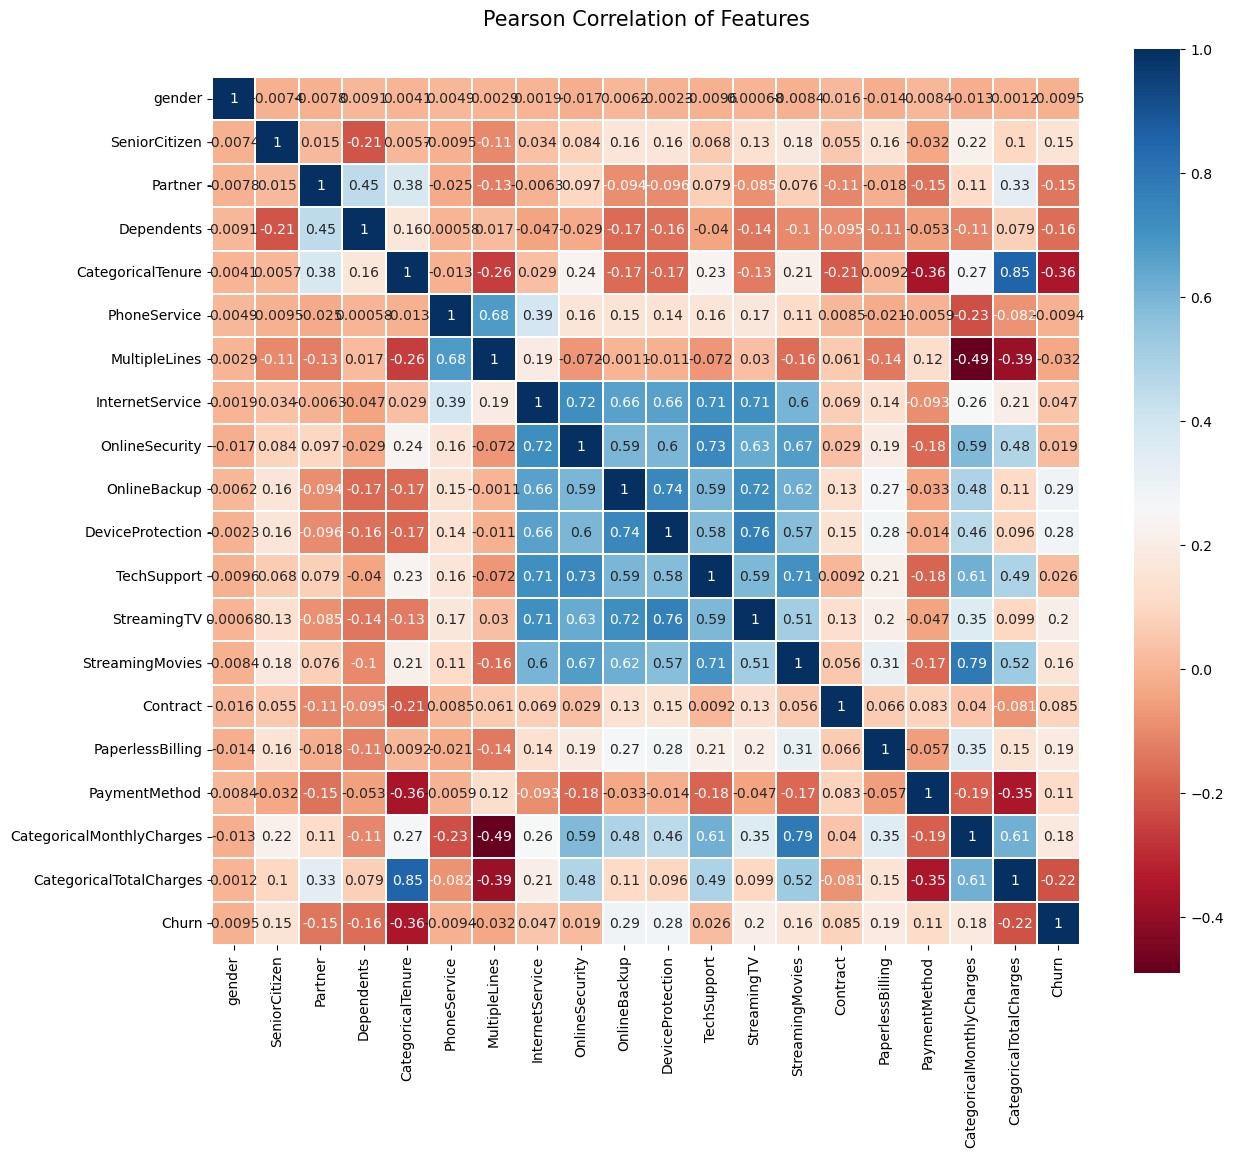

In [43]:
#смотрим кореляцию у признаков
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(telecom_ml.astype(float).corr(),linewidths=0.1,vmax=1.0,
            square=True, cmap=colormap, linecolor='white', annot=True)




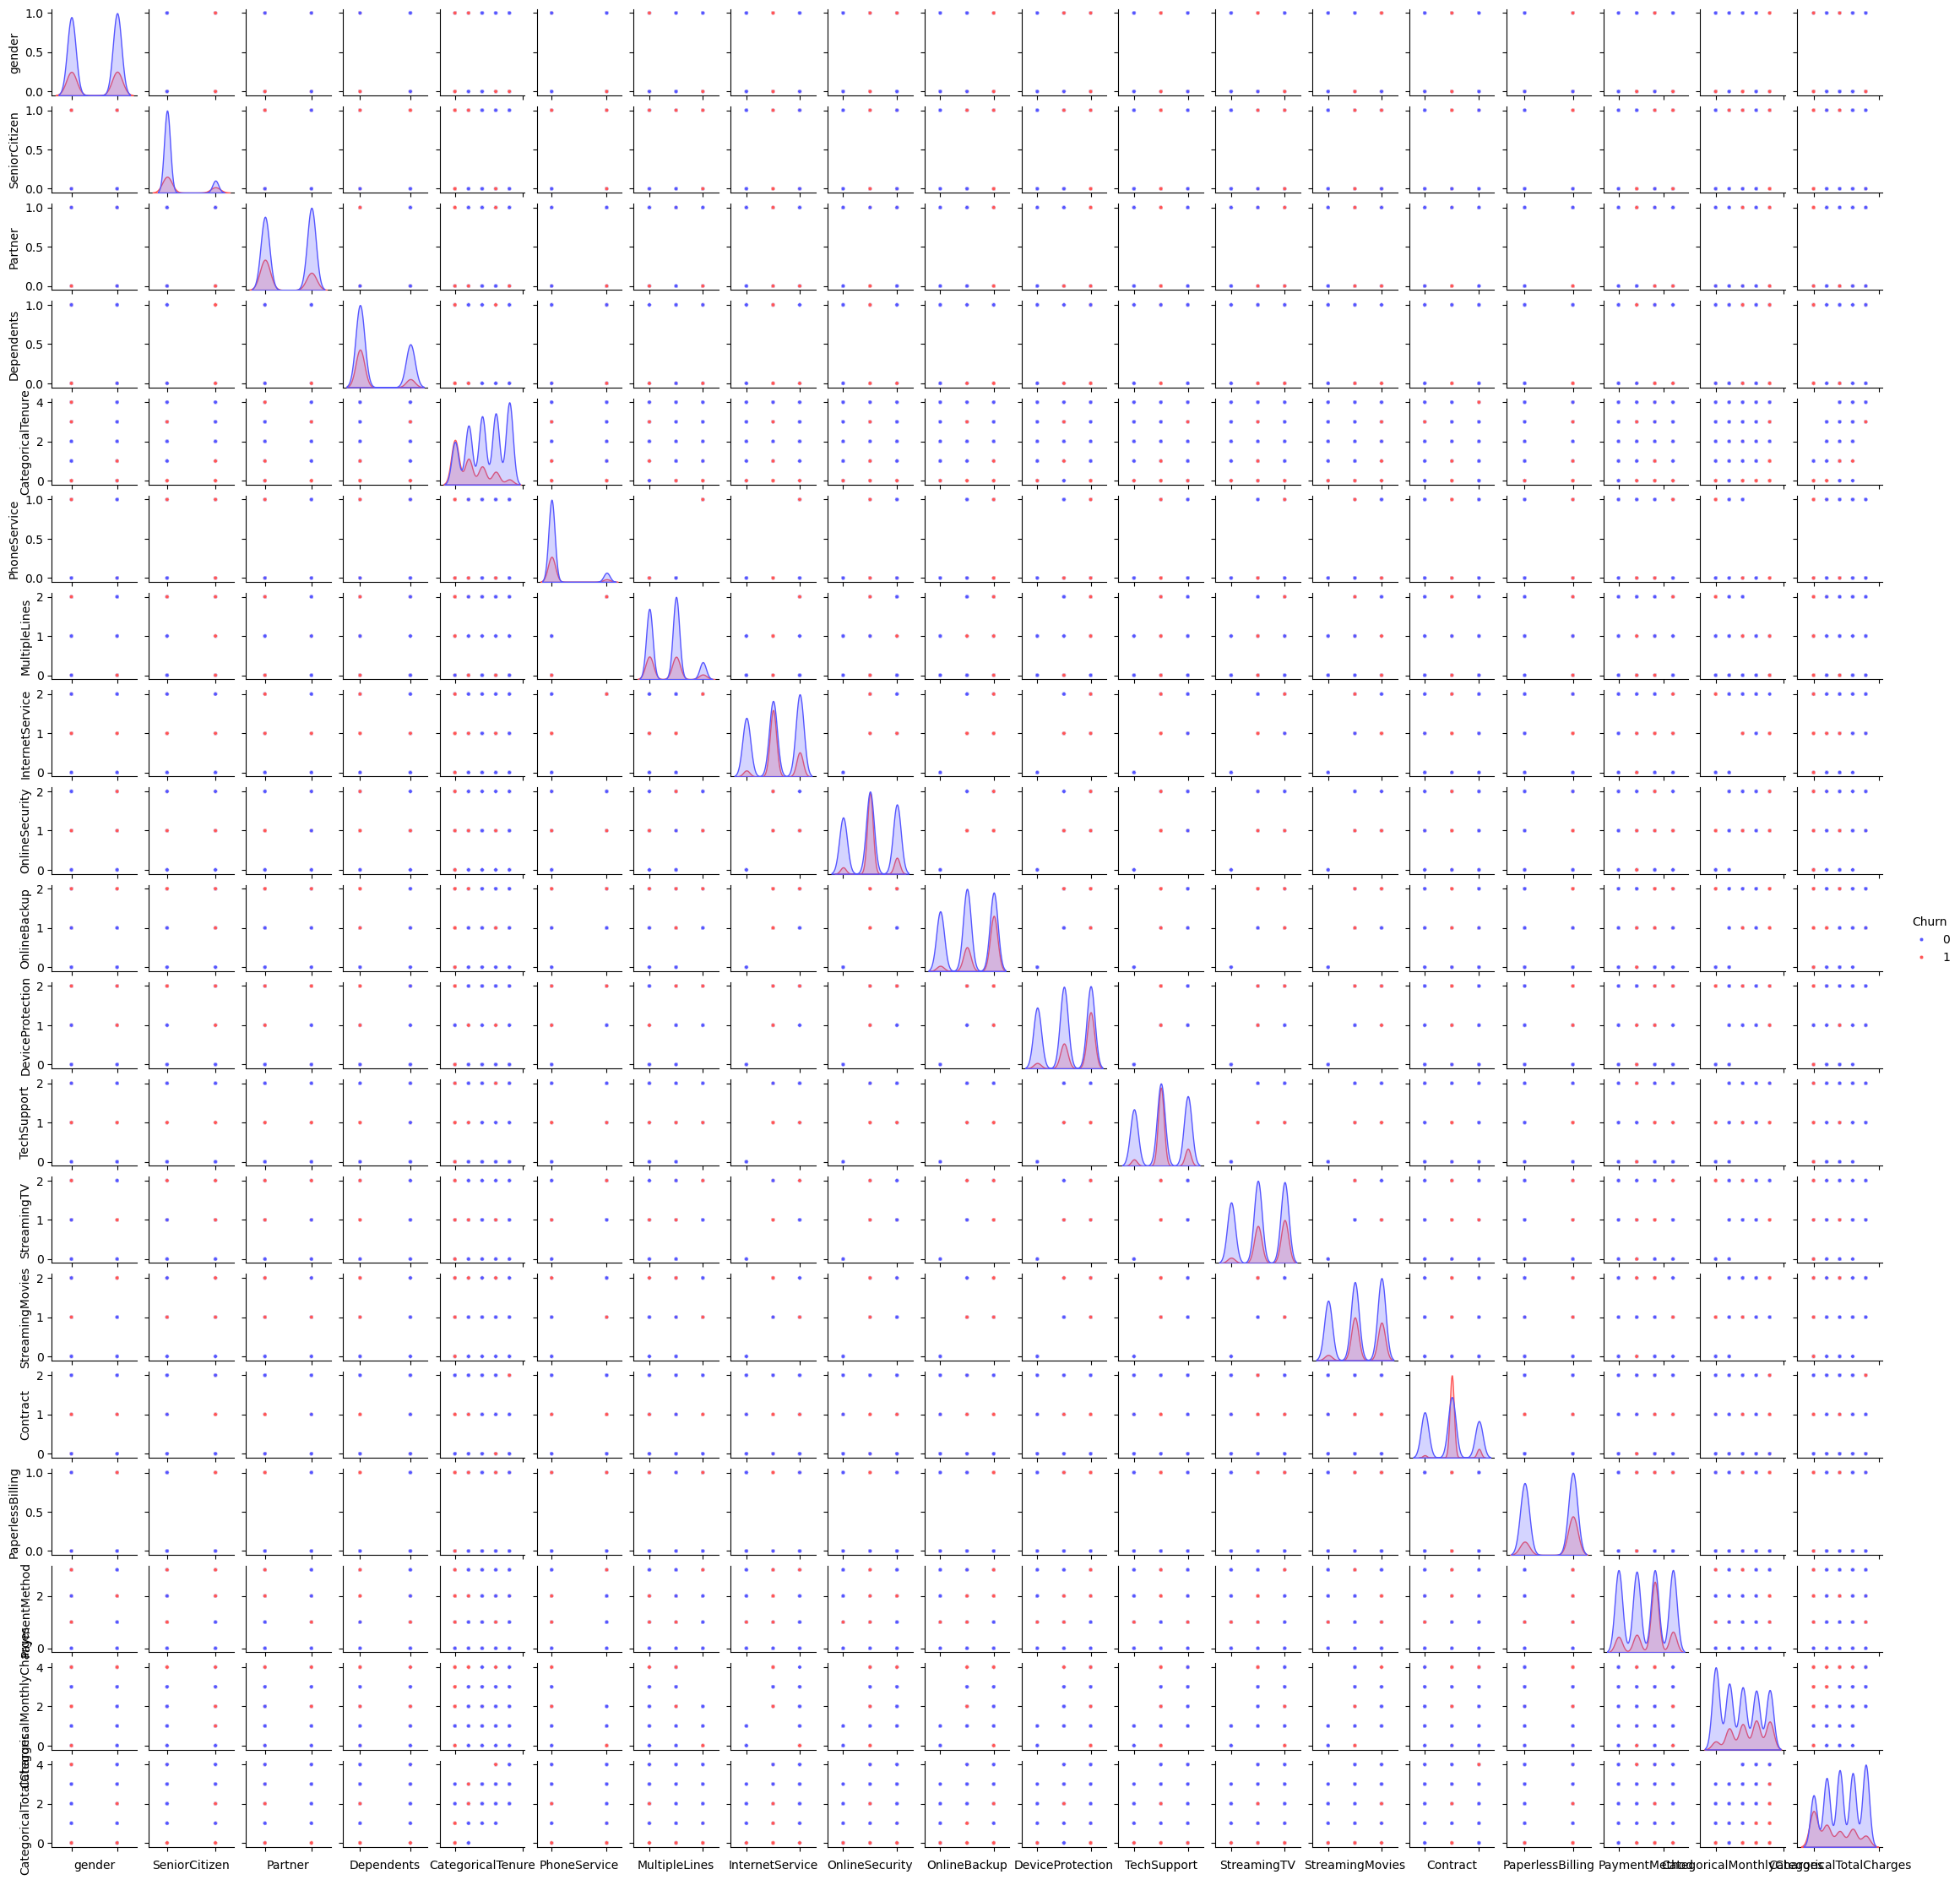

In [44]:
#создадим несколько парных диаграмм, понаблюдаем за распределением данных от одного объекта к другому
g = sns.pairplot(telecom_ml,
                 hue='Churn', palette = 'seismic', size=1.2, plot_kws=dict(s=10))
g.set(xticklabels=[])

Пропуски в данных до обработки: 0
Пропуски в данных после обработки: 0


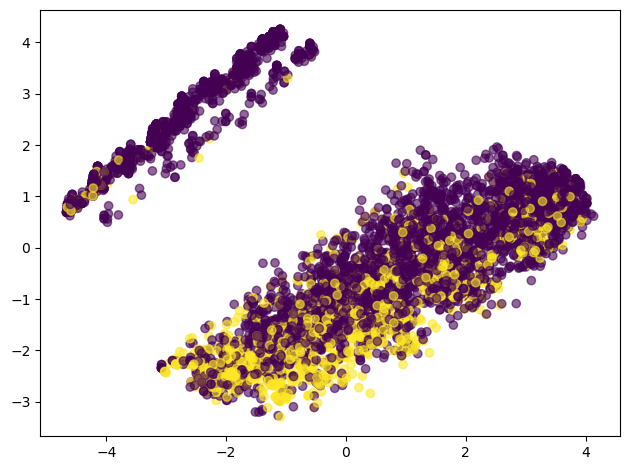

In [45]:
#добавляем библиотеку для разделения дата сета на тренировочный и валидационный
from sklearn.model_selection import train_test_split
#выделяем целевую переменную и признаки


# Выделяем целевую переменную и признаки
X = telecom_ml.drop('Churn', axis=1)
y = telecom_ml['Churn']

#проверяем и обрабатываем пропуски
print(f"Пропуски в данных до обработки: {X.isnull().sum().sum()}")

#заполняем пропуски медианой
X_filled = X.fillna(X.median())

# Присваиваем обработанные данные
X = X_filled

#проверяем что пропусков нет
print(f"Пропуски в данных после обработки: {X.isnull().sum().sum()}")
#разделение на тренировочную и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=17
)
#визуализация выборки
#применяем PCA для уменьшения размерности до 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)


plt.tight_layout()
plt.show()

# 3. Построение моделей для прогнозирования оттока

In [46]:
#добавляем библиотеки основных моделей
from sklearn.model_selection import (GridSearchCV,
                                     train_test_split,
                                     StratifiedKFold)

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

#выбираем стандартные параметры базовых алгоритмов для 5-кратной кросс-валидации с помощью GridSearchCV
gbc_params = {'learning_rate': np.arange(0.1, 0.6, 0.1)} # GradientBoostingClassifier

rfc_params = {'n_estimators': range(10, 100, 10), # RandomForestClassifier
              'min_samples_leaf': range(1, 5)}

svc_params = {'kernel': ['linear', 'rbf'], # SVC
              'C': np.arange(0.1, 1, 0.2)}

lr_params = {'C': np.arange(0.5, 1, 0.1)}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)


In [47]:
#Обучение каждого из объектов из 1-го пункта на получившейся при разбиении тренировочной выборке
lr = LogisticRegression(random_state=17)
lr_grid = GridSearchCV(lr, lr_params, cv=skf, scoring='accuracy')
lr_grid.fit(X_train, y_train)

rfc = RandomForestClassifier(random_state=17)
rfc_grid = GridSearchCV(rfc, rfc_params, cv=skf, scoring='accuracy')
rfc_grid.fit(X_train, y_train)

gbc = GradientBoostingClassifier(random_state=17)
gbc_grid = GridSearchCV(gbc, gbc_params, cv=skf, scoring='accuracy')
gbc_grid.fit(X_train, y_train)

svc = SVC(random_state=17)
svc_grid = GridSearchCV(svc, svc_params, cv=skf, scoring='accuracy')
svc_grid.fit(X_train, y_train)

,estimator,SVC(random_state=17)
,param_grid,"{'C': array([0.1, 0....5, 0.7, 0.9]), 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.9000000000000001


In [48]:
#вывод лучших параметров
print("GBC best params:", gbc_grid.best_params_)
print("RFC best params:", rfc_grid.best_params_) 
print("SVC best params:", svc_grid.best_params_)
print("LR best params:", lr_grid.best_params_)

GBC best params: {'learning_rate': 0.1}
RFC best params: {'min_samples_leaf': 4, 'n_estimators': 30}
SVC best params: {'C': 0.9000000000000001, 'kernel': 'linear'}
LR best params: {'C': 0.7}


In [49]:
#создаем модели с лучшими параметрами из GridSearch
lr_best = LogisticRegression(C=0.7, random_state=17)
rfc_best = RandomForestClassifier(min_samples_leaf=4, n_estimators=30, random_state=17)
gbc_best = GradientBoostingClassifier(learning_rate=0.1, random_state=17)
svc_best = SVC(C=0.9000000000000001, kernel='linear', random_state=17, probability=True)

In [50]:
#обучаем модели
models = [lr_best, rfc_best, gbc_best, svc_best]
for model in models:
    model.fit(X_train, y_train)

In [51]:
#задаем стандартные паарметры для мета-алгоритма
xgb_params = {'n_estimators': range(10, 100, 5),
              'eta': np.arange(0.1, 1., .1),
              'min_child_weight': range(1, 10, 1),
              'subsample': np.arange(0.1, 1., 0.2)}

In [52]:
from sklearn.metrics import roc_auc_score, accuracy_score

#создаем матрицу мета-признаков для валидационных данных
meta_mtrx = np.empty((X_valid.shape[0], len(models)))  # (кол-во объектов, 4 алгоритма)

for n, model in enumerate(models):
    meta_mtrx[:, n] = model.predict(X_valid)
    predicted = model.predict(X_valid)
    print(f'{n} auc: {roc_auc_score(y_valid, predicted):.4f}')
    print(f'{n} Accuracy: {accuracy_score(y_valid, predicted):.4f}')

0 auc: 0.6942
0 Accuracy: 0.7996
1 auc: 0.6895
1 Accuracy: 0.7957
2 auc: 0.7010
2 Accuracy: 0.8023
3 auc: 0.6789
3 Accuracy: 0.7945


In [53]:
#используем XGBClassifier
meta = XGBClassifier(random_state=17)
meta_grid = GridSearchCV(meta, xgb_params, cv=skf, scoring='accuracy')
meta_grid.fit(meta_mtrx, y_valid)

print("Лучшие параметры мета-алгоритма:", meta_grid.best_params_)
print("Лучший score мета-алгоритма:", meta_grid.best_score_)

Лучшие параметры мета-алгоритма: {'eta': 0.9, 'min_child_weight': 4, 'n_estimators': 80, 'subsample': 0.1}
Лучший score мета-алгоритма: 0.8084586815227484


In [54]:
#для дальнейшего пердикта мета-модели берем весь датасет
X_train_full = telecom_ml.drop('Churn', axis=1)  
y_train_full = telecom_ml['Churn']               
X_test_full = telecom_ml.drop('Churn', axis=1) 


In [55]:
#проверяем, что пропусков нет
print(f"Пропуски в X_train_full: {X_train_full.isnull().sum().sum()}")
print(f"Пропуски в X_test_full: {X_test_full.isnull().sum().sum()}")

Пропуски в X_train_full: 0
Пропуски в X_test_full: 0


In [56]:
#cоздаем модели с лучшими параметрами

lr_best = LogisticRegression(C=0.7, random_state=17)
rfc_best = RandomForestClassifier(min_samples_leaf=4, n_estimators=30, random_state=17)
gbc_best = GradientBoostingClassifier(learning_rate=0.1, random_state=17)
svc_best = SVC(C=0.9000000000000001, kernel='linear', random_state=17, probability=True)

models_best = [lr_best, rfc_best, gbc_best, svc_best]

In [57]:
#мета-алгоритм с ВСЕМИ лучшими параметрами
meta_best = XGBClassifier(
    eta=0.9,                         #learning_rate
    n_estimators=80,                 #количество деревьев
    min_child_weight=4,              #минимальный вес для разделения
    subsample=0.1,                   #доля samples для обучения каждого дерева
    random_state=17
)


In [58]:
#добавляем функцию для расчета Stacking AUC и вывода предсказаний
from sklearn.model_selection import cross_val_predict
def stacking(models, meta_alg, data_train, targets_train, data_test, targets_test=None, random_state=None, test_size=None, cv=5):
    if test_size is None:
        #используем кросс-валидацию для создания мета-признаков
        
        #определяем матрицу meta_mtrx
        meta_mtrx = np.empty((data_train.shape[0], len(models)))
        
        #цикл для заполнения матрицы meta_mtrx
        for n, model in enumerate(models):
            #каждый столбец метапризнаков заполняется с помощью cross_val_predict
            meta_mtrx[:, n] = cross_val_predict(model, data_train, targets_train, cv=cv, method='predict')
            
            #обучаем каждый базовый алгоритм на полном тренировочном датасете
            model.fit(data_train, targets_train)
        
        #обучаем мета-алгоритм на матрице метапризнаков
        meta_alg.fit(meta_mtrx, targets_train)
        
        #определяем матрицу meta_mtrx_test
        meta_mtrx_test = np.empty((data_test.shape[0], len(models)))
        
        #цикл для заполнения матрицы meta_mtrx_test
        for n, model in enumerate(models):
            # Матрица заполняется предсказаниями базовых моделей на тестовых данных
            meta_mtrx_test[:, n] = model.predict(data_test)
        
        #предсказания мета-алгоритма для значений матрицы meta_mtrx_test
        meta_predictions = meta_alg.predict(meta_mtrx_test)
        
        #проверка для targets_test и вывод roc_auc_score
        if targets_test is not None:
            auc_score = roc_auc_score(targets_test, meta_predictions)
            print(f"Stacking AUC: {auc_score:.4f}")
            
        return meta_predictions
    
    elif test_size > 0 and test_size < 1:
        #деление data_train и targets_train на тренировочные и валидационные данные
        X_train, X_valid, y_train, y_valid = train_test_split(
            data_train, targets_train, test_size=test_size, random_state=random_state
        )
        
        #определение матрицы meta_mtrx
        meta_mtrx = np.empty((X_valid.shape[0], len(models)))
        
        #цикл для заполнения meta_mtrx
        for n, model in enumerate(models):
            #модель обучается на тренировочных данных из разбиения
            model.fit(X_train, y_train)
            #матрица заполняется значениями предсказаний моделей на валидационных данных
            meta_mtrx[:, n] = model.predict(X_valid)
        
        #обучение мета-алгоритма на значениях матрицы meta_mtrx
        meta_alg.fit(meta_mtrx, y_valid)
        
        #определение матрицы meta_mtrx_test
        meta_mtrx_test = np.empty((data_test.shape[0], len(models)))
        
        #цикл для заполнения meta_mtrx_test
        for n, model in enumerate(models):
            #матрица заполняется предсказаниями базовых моделей на тестовых данных
            meta_mtrx_test[:, n] = model.predict(data_test)
        
        #предсказания мета-алгоритма для значений матрицы meta_mtrx_test
        meta_predictions = meta_alg.predict(meta_mtrx_test)
        
        #проверка существования targets_test
        if targets_test is not None:
            #вывод метрики roc_auc_score для предсказаний мета-алгоритма
            auc_score = roc_auc_score(targets_test, meta_predictions)
            print(f"Stacking AUC: {auc_score:.4f}")
            
        return meta_predictions
    
    else:
        raise ValueError("test_size must be between 0 and 1")

In [59]:
# Запуск stacking
predictions = stacking(
    models=models_best, 
    meta_alg=meta_best, 
    data_train=X_train_full,  
    targets_train=y_train_full,  
    data_test=X_test_full,    
    targets_test=None,
    test_size=None,
    cv=5
)

In [60]:
#разделим датасет по принципу стандарного разделения
#проверяем и обрабатываем пропуски
print(f"Пропуски в данных до обработки: {X.isnull().sum().sum()}")
#определяем признаки
X_03 = telecom_ml.drop('Churn', axis=1)  
y_03 = telecom_ml['Churn']
print(f"Пропуски в данных до обработки: {X.isnull().sum().sum()}")

#заполняем пропуски медианой
X_filled = X_03.fillna(X_03.median())

#присваиваем обработанные данные
X_03 = X_filled

#проверяем, что пропусков нет
print(f"Пропуски в данных после обработки: {X_03.isnull().sum().sum()}")
#разделение на тренировочную и валидационную выборки
X_03_train, X_03_valid, y_03_train, y_03_valid = train_test_split(
    X_03, y_03, 
    test_size=0.3, 
    random_state=17
)

print(f"Размер тренировочной выборки: {X_03_train.shape}")
print(f"Размер валидационной выборки: {X_03_valid.shape}")

Пропуски в данных до обработки: 0
Пропуски в данных до обработки: 0
Пропуски в данных после обработки: 0
Размер тренировочной выборки: (4190, 19)
Размер валидационной выборки: (1796, 19)


In [61]:

from sklearn.feature_selection import mutual_info_classif

#анализ важности признаков перед обучением
mi_scores = mutual_info_classif(X_03_train, y_03_train)
feature_names = X_03.columns

for i, (score, name) in enumerate(zip(mi_scores, feature_names)):
    print(f"{name}: {score:.4f}")

gender: 0.0028
SeniorCitizen: 0.0104
Partner: 0.0150
Dependents: 0.0176
CategoricalTenure: 0.0674
PhoneService: 0.0118
MultipleLines: 0.0000
InternetService: 0.0529
OnlineSecurity: 0.0534
OnlineBackup: 0.0305
DeviceProtection: 0.0358
TechSupport: 0.0645
StreamingTV: 0.0339
StreamingMovies: 0.0301
Contract: 0.1044
PaperlessBilling: 0.0270
PaymentMethod: 0.0413
CategoricalMonthlyCharges: 0.0204
CategoricalTotalCharges: 0.0264


In [62]:

#посмотрим, как отработает модель на стандартном разделении датасета без кросс валидации
#список базовых алгоритмов, модели с лучшими параметрами уже созданы
models = [lr_best, rfc_best, gbc_best, svc_best]

#определяем мету-модель
meta = XGBClassifier(eta=0.9, n_estimators=80, min_child_weight=4, subsample=0.1, random_state=17)

#вызов функции
predictions2 = stacking(models, meta, X_03_train, y_03_train, X_03_valid, y_03_valid, test_size=0.3, random_state=17)
print(f"Предсказания: {predictions2}") 

Stacking AUC: 0.6666
Предсказания: [0 0 0 ... 1 0 1]


In [ ]:
#вывод: AUK заметно ниже в сравнении с кросс-валидацией

# 4. Сравнение качества моделей

In [63]:
#создаем DataFrame для сравнения предсказаний с оригиналом
comparison_df = pd.DataFrame({
    'Unnamed: 0': telecom_ml.index,
    'Actual_Churn': y_train_full.values,
    'Predicted_Churn': predictions 
})
print("сравнение предсказаний модели meta-best (обученной с помощью кросс-валидации) с оригинальными значениями:")
print(comparison_df.head(20))

сравнение предсказаний модели meta-best (обученной с помощью кросс-валидации) с оригинальными значениями:
    Unnamed: 0  Actual_Churn  Predicted_Churn
0            0             0                0
1            1             0                0
2            2             1                0
3            3             0                1
4            4             0                0
5            5             0                0
6            6             0                0
7            7             0                1
8            8             0                0
9            9             0                0
10          10             0                0
11          11             1                0
12          12             0                0
13          13             0                0
14          14             0                0
15          15             0                0
16          16             0                1
17          17             0                0
18          18      

In [64]:
#создаем DataFrame для сравнения предсказаний без крос-валидации с оригиналом
valid_indices = X_03_valid.index

comparison_03_df = pd.DataFrame({
    'Unnamed: 0': valid_indices, 
    'Actual_Churn': y_03_valid.values,  
    'Predicted_Churn': predictions2 
})
print("сравнение предсказаний модели meta (обученной без кросс-валидации) с оригинальными значениями:")
print(comparison_03_df.head(20))

сравнение предсказаний модели meta (обученной без кросс-валидации) с оригинальными значениями:
    Unnamed: 0  Actual_Churn  Predicted_Churn
0         2639             0                0
1         2102             0                0
2         3855             0                0
3         3813             1                1
4         2213             0                0
5         5291             0                0
6         1485             0                1
7         1682             0                1
8         1723             0                0
9         4262             0                0
10        4891             0                0
11        3032             0                0
12        3700             0                0
13        4846             0                0
14        4702             0                0
15        1710             0                0
16         193             0                0
17        3133             0                0
18        3180             0   

Вычисление AUC для всех моделей:
Модель 1 (LogisticRegression): AUC = 0.6842, Accuracy = 0.7940
Модель 2 (RandomForestClassifier): AUC = 0.6781, Accuracy = 0.7912
Модель 3 (GradientBoostingClassifier): AUC = 0.6889, Accuracy = 0.7990
Модель 4 (SVC): AUC = 0.6782, Accuracy = 0.7934
Meta (стандартное): AUC = 0.6666, Accuracy = 0.7951
Meta-best (CV): AUC = 0.7061, Accuracy = 0.8126


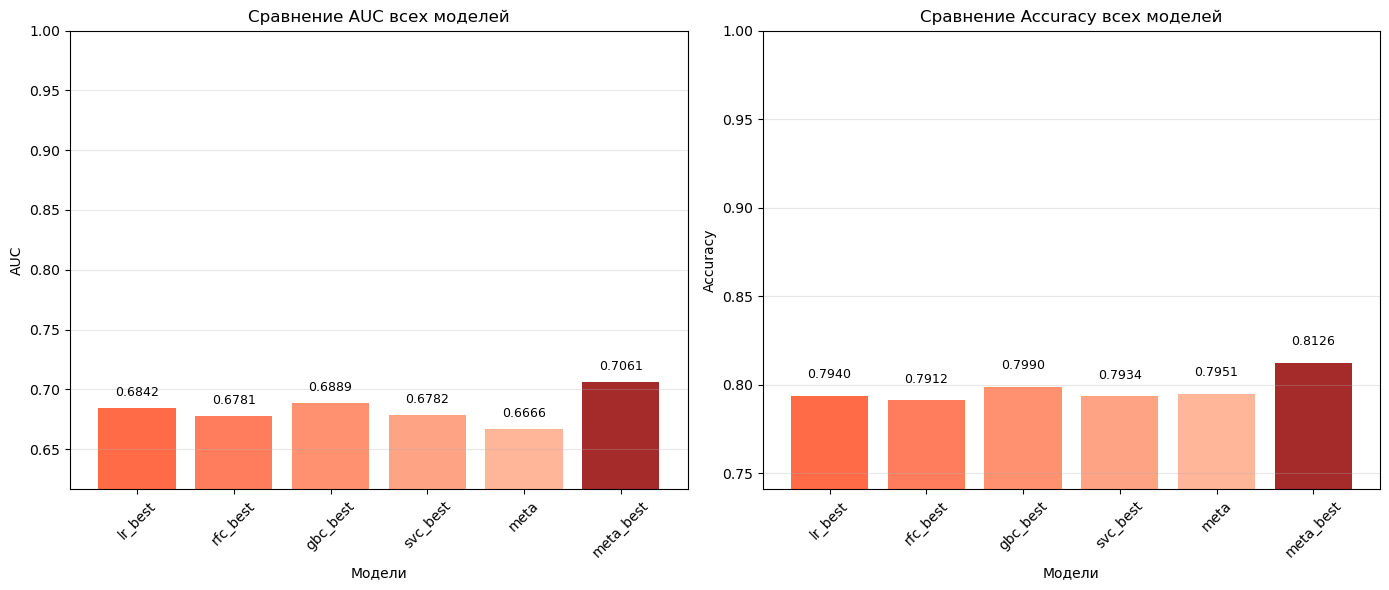

In [65]:
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

#вычисляем AUC для всех моделей на одних и тех же данных
#используем X_valid и y_valid для базовых моделей

print("Вычисление AUC для всех моделей:")

#базовые модели (lr_best, rfc_best, gbc_best, svc_best)
auc_values = []
accuracy_values = []

for i, model in enumerate(models):
    pred = model.predict(X_valid)
    auc = roc_auc_score(y_valid, pred)
    acc = accuracy_score(y_valid, pred)
    auc_values.append(auc)
    accuracy_values.append(acc)
    print(f"Модель {i+1} ({model.__class__.__name__}): AUC = {auc:.4f}, Accuracy = {acc:.4f}")

#мeta модель (стандартное разделение)
#используем predictions2 на X_03_valid
auc_meta = roc_auc_score(y_03_valid, predictions2)
acc_meta = accuracy_score(y_03_valid, predictions2)
auc_values.append(auc_meta)
accuracy_values.append(acc_meta)
print(f"Meta (стандартное): AUC = {auc_meta:.4f}, Accuracy = {acc_meta:.4f}")

#мeta-best модель (кросс-валидация)
#используем predictions на X_test_full
auc_meta_best = roc_auc_score(y_train_full, predictions)
acc_meta_best = accuracy_score(y_train_full, predictions)

auc_values.append(auc_meta_best)
accuracy_values.append(acc_meta_best)
print(f"Meta-best (CV): AUC = {auc_meta_best:.4f}, Accuracy = {acc_meta_best:.4f}")

#строим график
alg = ['lr_best', 'rfc_best', 'gbc_best', 'svc_best', 'meta', 'meta_best']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#график AUC
ax1.bar(alg, auc_values, color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', 'brown'])
ax1.set_title('Сравнение AUC всех моделей')
ax1.set_xlabel('Модели')
ax1.set_ylabel('AUC')
ax1.set_xticklabels(alg, rotation=45)
ax1.set_ylim([min(auc_values) - 0.05, 1.0])
ax1.grid(True, alpha=0.3, axis='y')

#добавляем значения на столбцы AUC
for i, v in enumerate(auc_values):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

#график Accuracy
ax2.bar(alg, accuracy_values, color=['#FF6A47', '#FF7D5C', '#FF9070', '#FFA385', '#FFB699', 'brown'])
ax2.set_title('Сравнение Accuracy всех моделей')
ax2.set_xlabel('Модели')
ax2.set_ylabel('Accuracy')
ax2.set_xticklabels(alg, rotation=45)
ax2.set_ylim([min(accuracy_values) - 0.05, 1.0])
ax2.grid(True, alpha=0.3, axis='y')

#добавляем значения на столбцы Accuracy
for i, v in enumerate(accuracy_values):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()



In [66]:
#сравнение предсказаний с оригиналом для meta и meta-best

print("сравнение предсказаний с оригиналом:")


#для meta
correct_meta = (comparison_03_df['Actual_Churn'] == comparison_03_df['Predicted_Churn']).sum()
total_meta = len(comparison_03_df)
accuracy_meta_df = correct_meta / total_meta
print(f"Meta: Правильных {correct_meta}/{total_meta}, Accuracy = {accuracy_meta_df:.4f}")

#для meta-best
correct_meta_best = (comparison_df['Actual_Churn'] == comparison_df['Predicted_Churn']).sum()
total_meta_best = len(comparison_df)
accuracy_meta_best_df = correct_meta_best / total_meta_best
print(f"Meta-best: Правильных {correct_meta_best}/{total_meta_best}, Accuracy = {accuracy_meta_best_df:.4f}")

сравнение предсказаний с оригиналом:
Meta: Правильных 1428/1796, Accuracy = 0.7951
Meta-best: Правильных 4864/5986, Accuracy = 0.8126
